In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [5]:
image = cv2.imread('/cameraman.tif', cv2.IMREAD_GRAYSCALE)

Text(0.5, 1.0, 'Original Image')

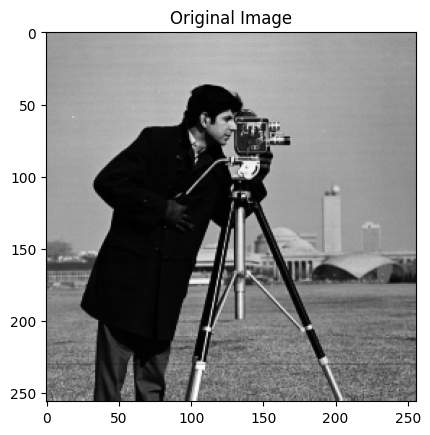

In [6]:
plt.imshow(image, cmap="gray")
plt.title("Original Image")

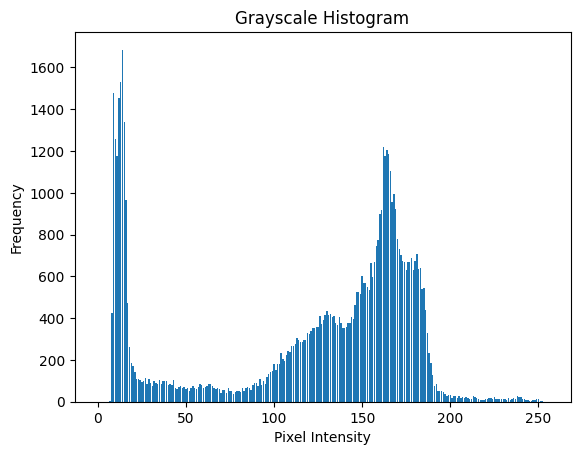

In [7]:
histogram = np.zeros(256, dtype=int)

for pixel_value in image.ravel():
  histogram[pixel_value] += 1

plt.bar(range(256), histogram)
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [8]:
def otsu_threshold(image):
  histogram = np.zeros(256, dtype=int)
  for pixel_value in image.ravel():
    histogram[pixel_value] += 1

  total_pixels = image.size
  prob = histogram / total_pixels

  best_threshold = 0
  best_variance = 0

  for t in range(256):
    # Background: 0..t | Foreground: t+1..255
    w_bg = np.sum(prob[:t+1])
    w_fg = np.sum(prob[t+1:])

    if w_bg == 0 or w_fg == 0:
      continue

    intensities = np.arange(256)

    mean_bg = np.sum(intensities[:t+1] * prob[:t+1]) / w_bg
    mean_fg = np.sum(intensities[t+1:] * prob[t+1:]) / w_fg

    # Between-class variance
    between_class_variance = w_bg * w_fg * (mean_bg - mean_fg) ** 2

    if between_class_variance > best_variance:
      best_variance = between_class_variance
      best_threshold = t

  return best_threshold

In [9]:
threshold_value = otsu_threshold(image)
print("Otsu's Optimal Threshold:", threshold_value)

Otsu's Optimal Threshold: 88


Text(0.5, 1.0, 'Otsu Binarized Image (t=88)')

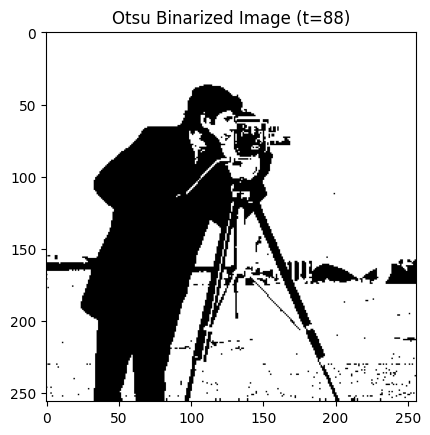

In [10]:
height, width = image.shape
binary_image = np.zeros((height, width), dtype=np.uint8)

for r in range(height):
  for c in range(width):
    if image[r, c] > threshold_value:
      binary_image[r, c] = 255
    else:
      binary_image[r, c] = 0

plt.imshow(binary_image, cmap="gray")
plt.title(f"Otsu Binarized Image (t={threshold_value})")

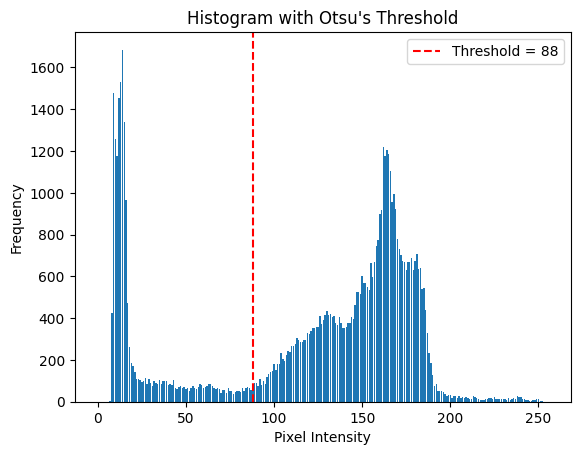

In [11]:
plt.bar(range(256), histogram)
plt.axvline(x=threshold_value, color='red', linestyle='--', label=f"Threshold = {threshold_value}")
plt.title("Histogram with Otsu's Threshold")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

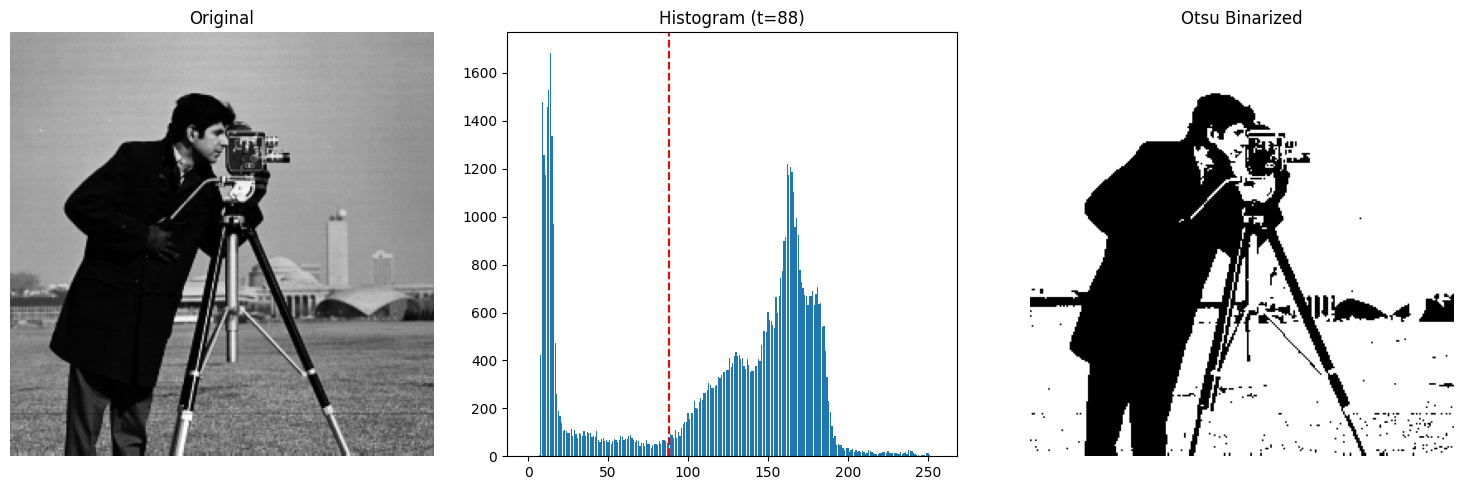

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].bar(range(256), histogram)
axes[1].axvline(x=threshold_value, color='red', linestyle='--')
axes[1].set_title(f"Histogram (t={threshold_value})")

axes[2].imshow(binary_image, cmap="gray")
axes[2].set_title("Otsu Binarized")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Manual Otsu Threshold: 88
OpenCV Otsu Threshold: 88.0


Text(0.5, 1.0, 'OpenCV Otsu (t=88.0)')

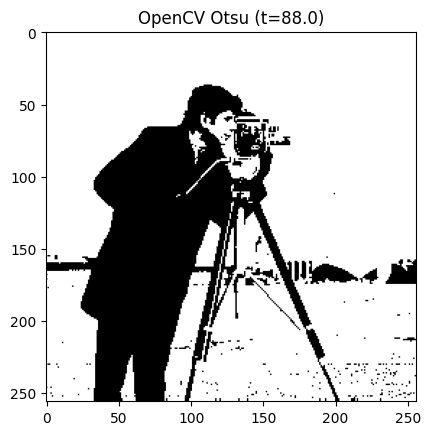

In [13]:
cv2_threshold_value, cv2_binary = cv2.threshold(
    image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Manual Otsu Threshold:", threshold_value)
print("OpenCV Otsu Threshold:", cv2_threshold_value)

plt.imshow(cv2_binary, cmap="gray")
plt.title(f"OpenCV Otsu (t={cv2_threshold_value})")